In [1]:
import json
from collections import Counter
import matplotlib.pyplot as plt
from itertools import product
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np


def print_code_file(file_path, language="javascript"):
    file_path = Path(file_path)
    code = file_path.read_text(encoding="utf-8")

    display(Markdown(f"### `{file_path}`\n\n```{language}\n{code}\n```"))

In [ ]:
# Files with few or no functions
files_to_rm = []
for filepath in ["../data/empty_p5functions.json", "../data/less_than_3_p5functions.json"]:
    with open(filepath) as f:
        files_to_rm += json.load(f)
files_to_rm = [f['artwork'] for f in files_to_rm]
files_to_rm[:3]

['AfroDisco/website/Courses/intelligence_learning/session7/07_03_color_classifier/sketch.js',
 'AfroDisco/website/Tutorials/P5JS/p5.js/05/5.3_p5.js_functions_and_return/sketch.js',
 'AfroDisco/website/Tutorials/P5JS/p5.js/08/8.09_p5.js_CSS_Selectors/sketch.js']

In [3]:
# Predictions
with open("../artworks/prompt_10_20260413/predictions.json") as f:
    raw_preds = json.load(f)
    for artwork in raw_preds:
        artwork['file_path'] = artwork['file_path'].replace("/home/rpinter/links/projects/def-baudry/shared/data/artworks/src/", "")

In [4]:
# Remove files with few or no functions
preds = [pred for pred in raw_preds if pred['file_path'] not in files_to_rm]

In [5]:
# Remove hallucinated lables in the entities
for artwork in preds:
    for label in ['auditory', 'visual', 'time_based']:
        if label in artwork['predicted_labels']['entities']:
            artwork['predicted_labels']['entities'].remove(label)

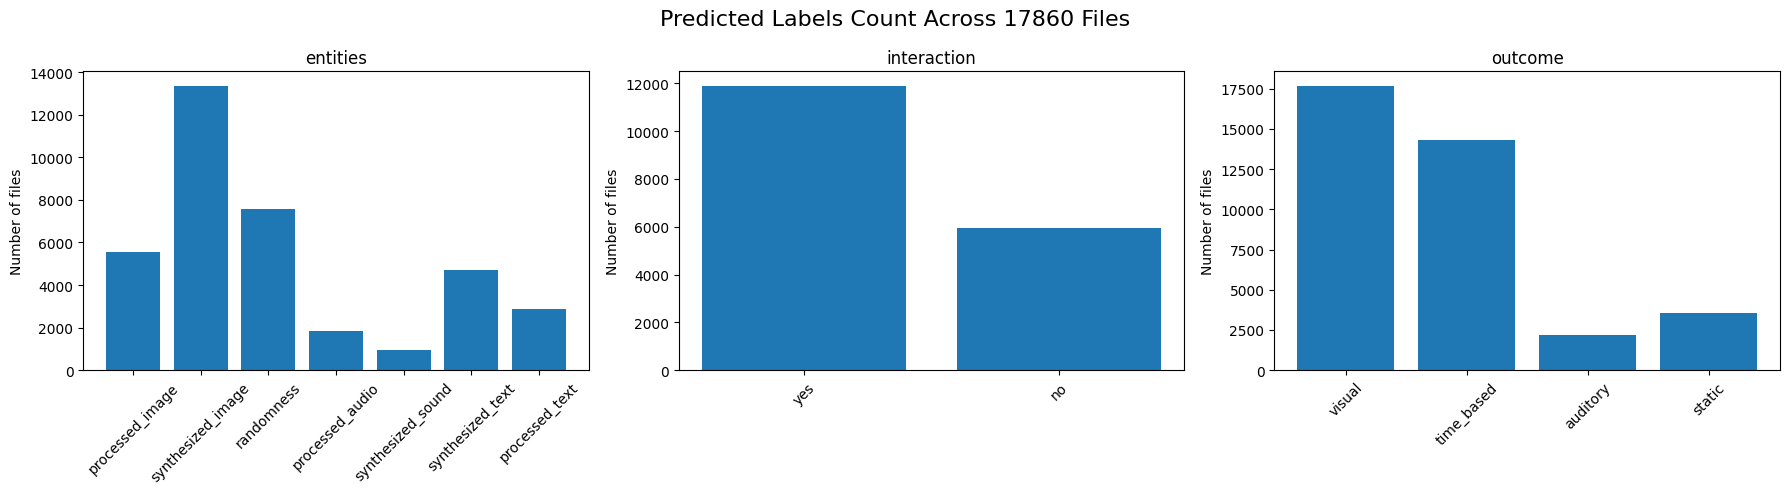

In [6]:
label_groups = ["entities", "interaction", "outcome"]
counts = {}

for group in label_groups:
    counter = Counter()
    for pred in preds:
        labels = pred.get("predicted_labels", {}).get(group, [])
        counter.update(labels)
    counts[group] = counter

total_files = len(preds)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, group in zip(axes, label_groups):
    counter = counts[group]
    labels = list(counter.keys())
    values = list(counter.values())
    ax.bar(labels, values)
    ax.set_title(group)
    ax.set_ylabel("Number of files")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle(f"Predicted Labels Count Across {total_files} Files", fontsize=16)
plt.tight_layout()
plt.show()

In [7]:
# Create string with label combination
for pred in preds:
    labels = pred["predicted_labels"]

    entities = labels.get("entities", [])
    interactions = labels.get("interaction", [])
    outcomes = labels.get("outcome", [])

    pred["label_combination"] = (
        f"entities={entities} | "
        f"interaction={interactions} | "
        f"outcome={outcomes}"
    )

/tmp/ipykernel_2493200/1868489608.py:16: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


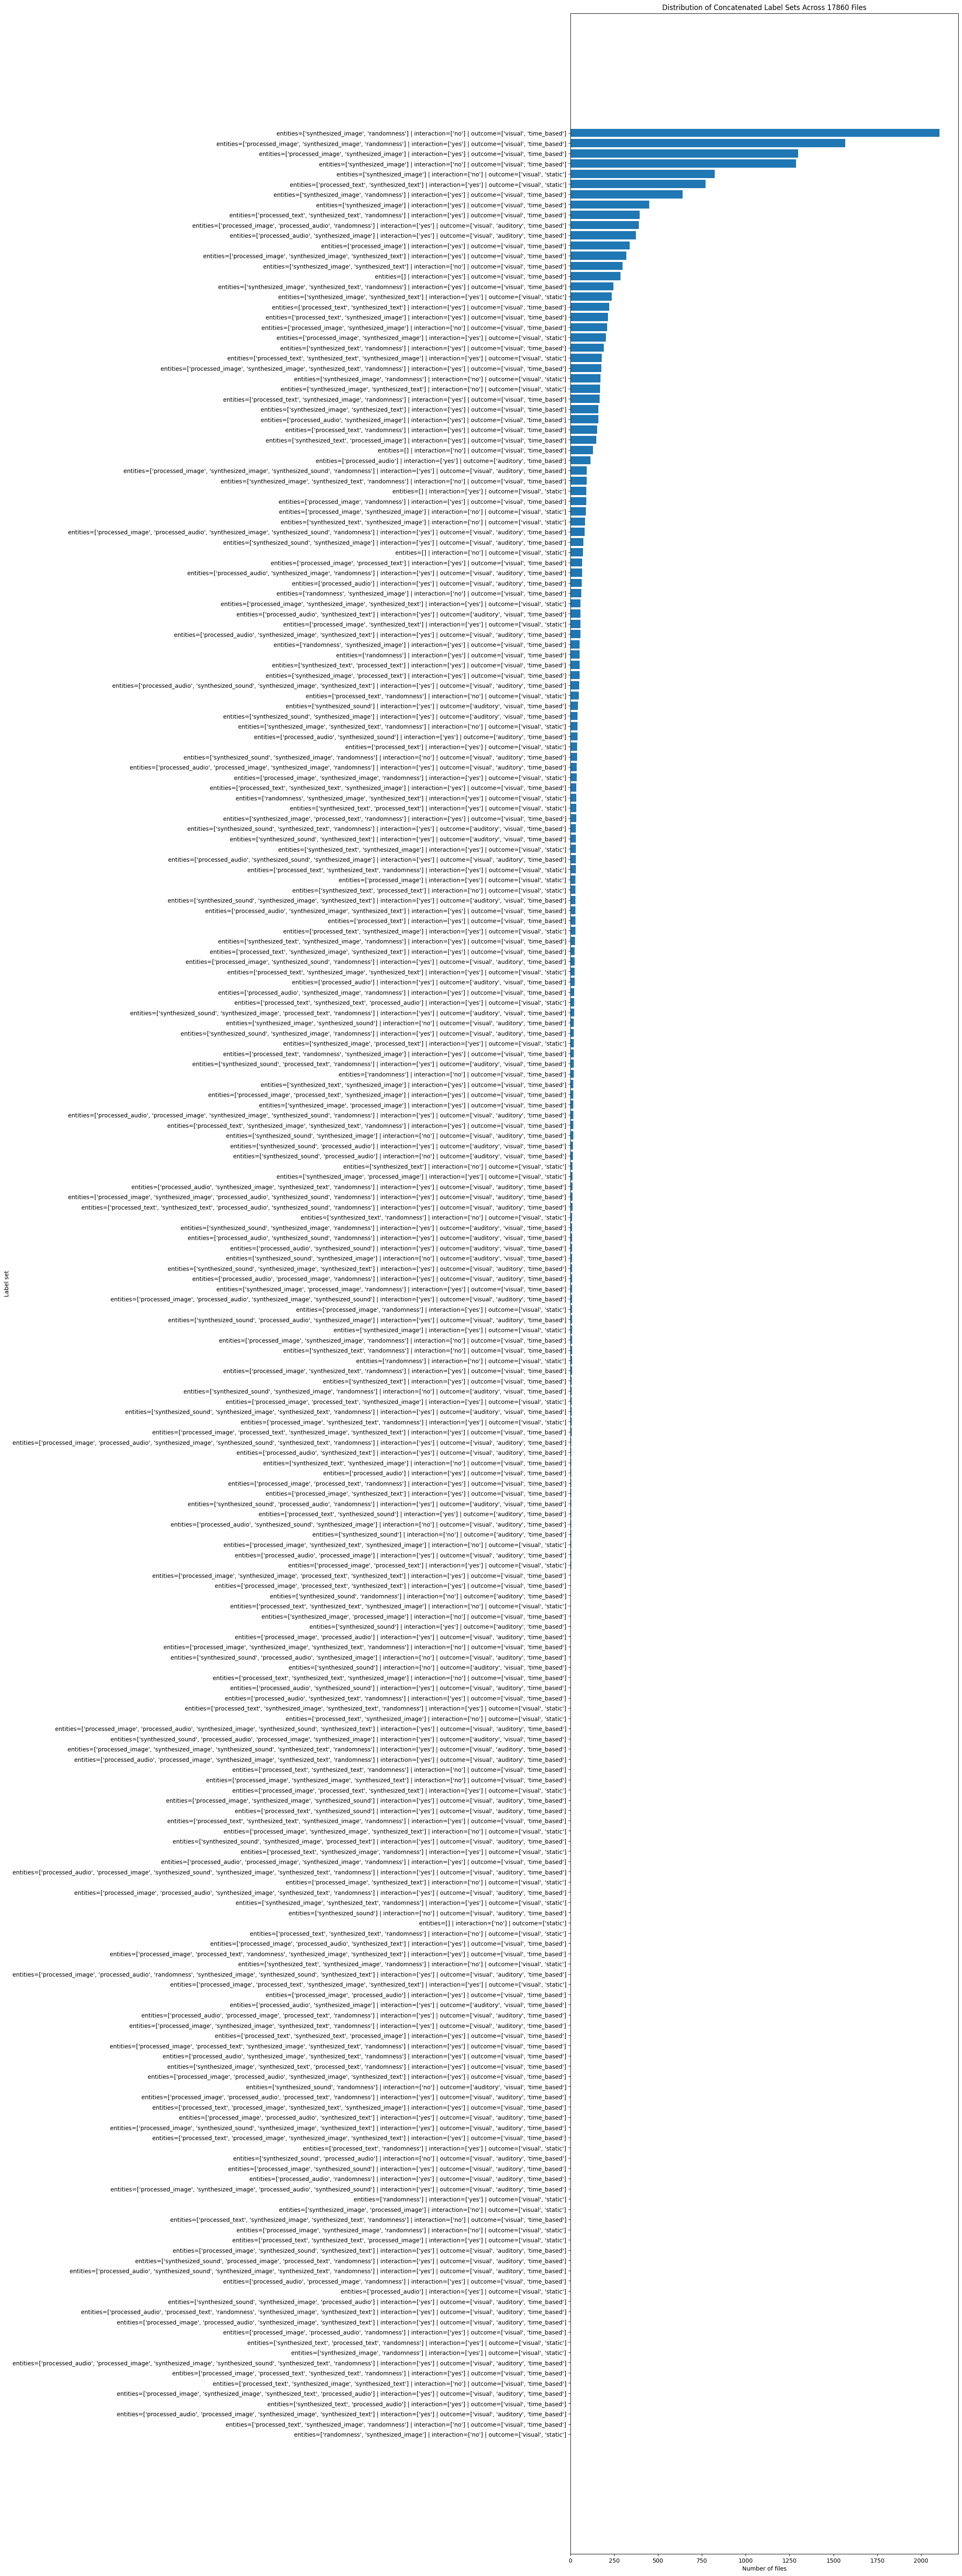

In [9]:
label_counts = Counter(pred["label_combination"] for pred in preds)

sorted_items = label_counts.most_common()

labels = [item[0] for item in sorted_items]
values = [item[1] for item in sorted_items]

plt.figure(figsize=(12, max(5, len(labels) * 0.35)))

plt.barh(labels, values)
plt.xlabel("Number of files")
plt.ylabel("Label set")
plt.title(f"Distribution of Concatenated Label Sets Across {len(preds)} Files")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [24]:
# Save processed file
with open("../data/clean_artworks_label_prediction.json", "w") as f:
    json.dump(preds, f, indent=2, ensure_ascii=False)


# Save processed file
with open("../data/clean_artworks_label_prediction_no_entities.json", "w") as f:
    no_entities = [pred for pred in preds if not pred['predicted_labels']['entities']]
    json.dump(no_entities, f, indent=2, ensure_ascii=False)


# Save processed file
with open("../data/clean_artworks_label_prediction_interactive_static.json", "w") as f:
    interactive_and_static = [pred for pred in preds if 'yes' in pred['predicted_labels']['interaction'] and 'static' in pred['predicted_labels']['outcome']]
    json.dump(interactive_and_static, f, indent=2, ensure_ascii=False)


# Save processed file
with open("../data/clean_artworks_label_prediction_no_intrand_visual_static.json", "w") as f:
    interactive_and_static = [pred for pred in preds if "entities=['synthesized_image'] | interaction=['no'] | outcome=['visual', 'time_based']" in pred['label_combination']]
    json.dump(interactive_and_static, f, indent=2, ensure_ascii=False)


    # Save processed file
with open("../data/clean_artworks_label_prediction_top9.json", "w") as f:
    interactive_and_static = [pred for pred in preds if "entities=['processed_image', 'processed_audio', 'randomness'] | interaction=['yes'] | outcome=['visual', 'auditory', 'time_based']" in pred['label_combination']]
    json.dump(interactive_and_static, f, indent=2, ensure_ascii=False)


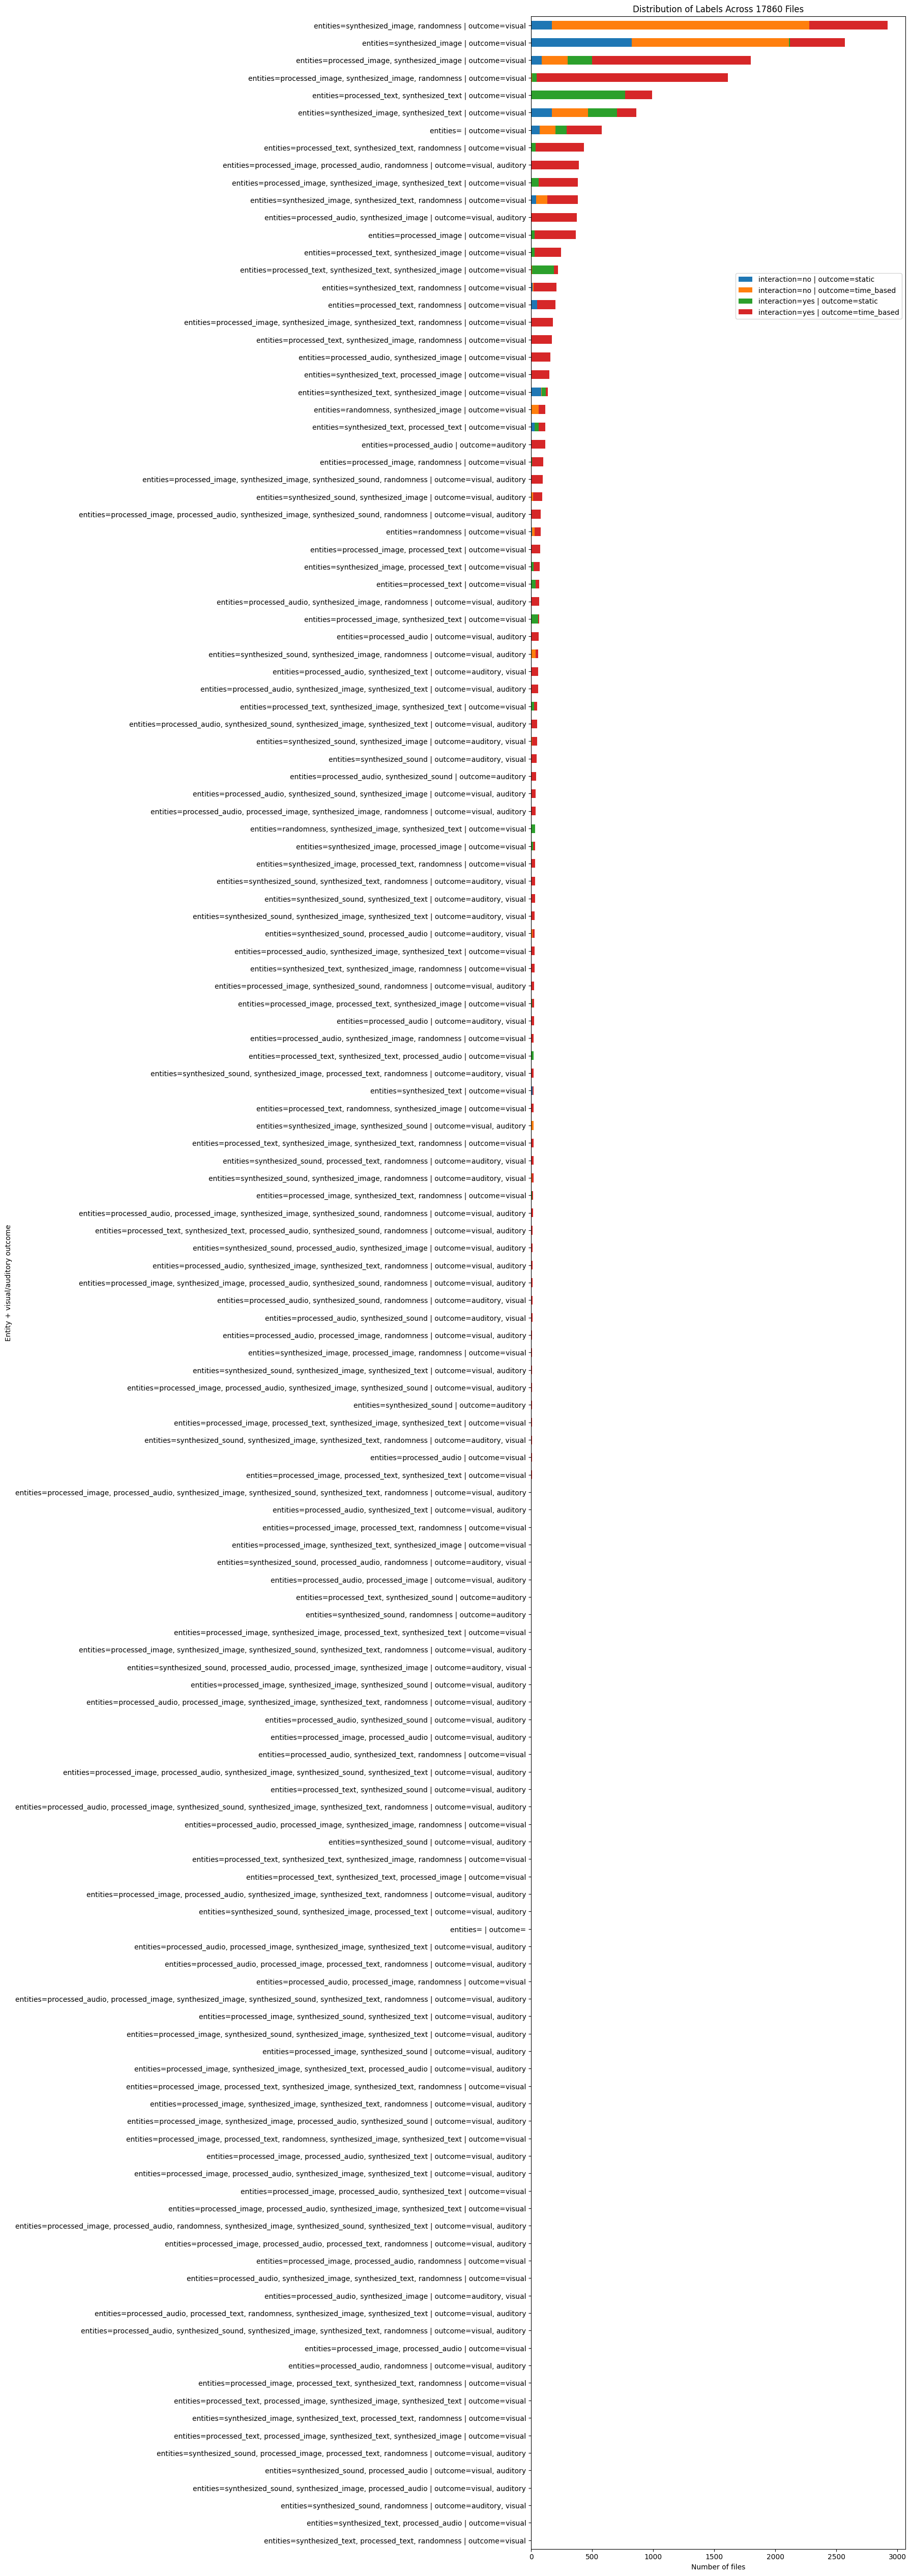

In [ ]:
rows = []

for pred in preds:
    labels = pred["predicted_labels"]

    entities = labels.get("entities", [])
    interactions = labels.get("interaction", [])
    outcomes = labels.get("outcome", [])

    # These stay in the bar label
    modality_outcomes = [
        x for x in outcomes
        if x in ["visual", "auditory"]
    ]

    axis_label = " | ".join([
        "entities=" + ", ".join(entities),
        "outcome=" + ", ".join(modality_outcomes),
    ])

    # These define the stacked colors
    time_outcomes = [
        x for x in outcomes
        if x in ["static", "time_based"]
    ]

    for interaction in interactions:
        for time_outcome in time_outcomes:
            rows.append({
                "axis_label": axis_label,
                "color_group": f"interaction={interaction} | outcome={time_outcome}",
            })

df_plot = pd.DataFrame(rows)

plot_data = pd.crosstab(
    df_plot["axis_label"],
    df_plot["color_group"]
)

plot_data["total"] = plot_data.sum(axis=1)

plot_data = (
    plot_data
    .sort_values("total", ascending=False)
    .drop(columns="total")
)

ax = plot_data.plot(
    kind="barh",
    stacked=True,
    figsize=(18, max(5, len(plot_data) * 0.35))
)

plt.xlabel("Number of files")
plt.ylabel("Entity + visual/auditory outcome")
plt.title(f"Distribution of Labels Across {len(preds)} Files")

plt.legend(
    loc="upper right",
    bbox_to_anchor=(1, 0.90)
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

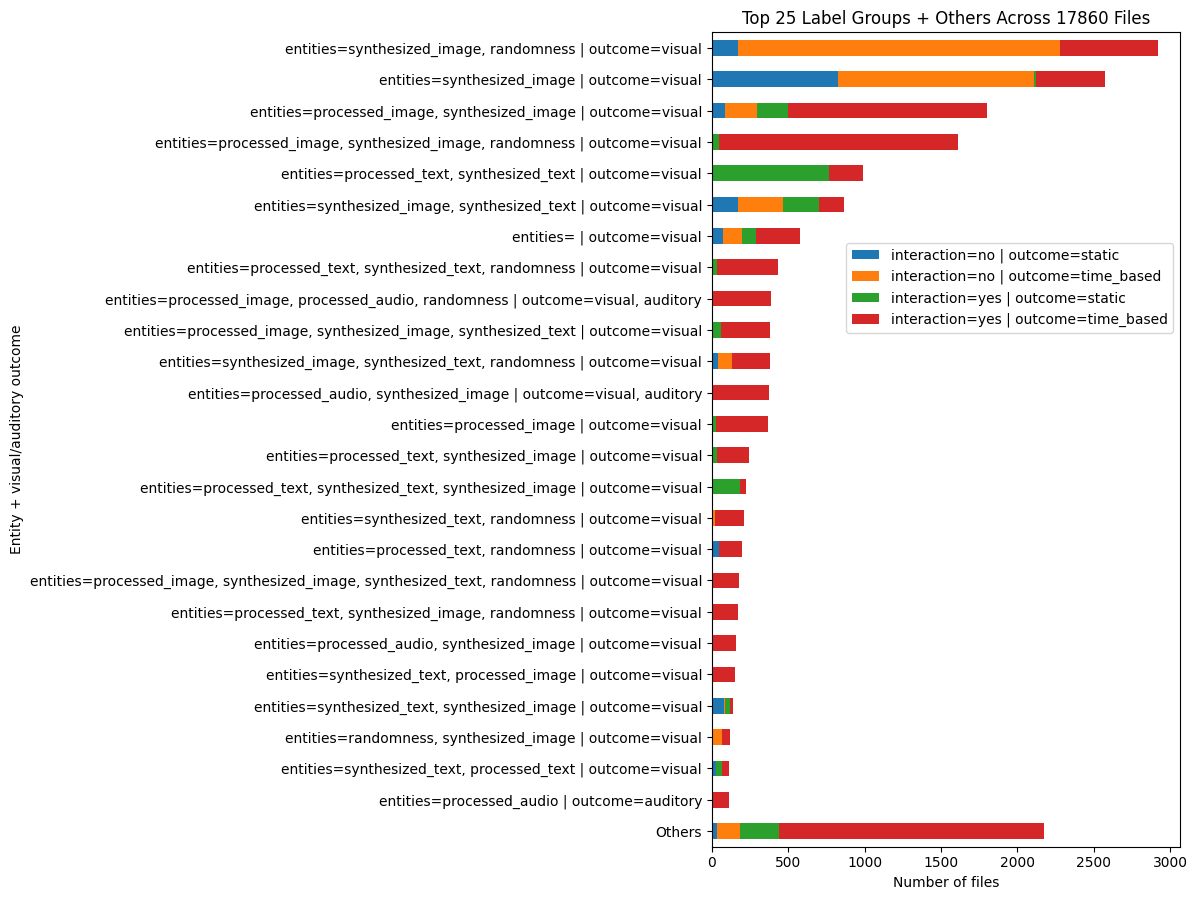

In [13]:
top_n = 25

plot_data["total"] = plot_data.sum(axis=1)

plot_data = plot_data.sort_values("total", ascending=False)

top_data = plot_data.head(top_n).drop(columns="total")
other_data = plot_data.iloc[top_n:].drop(columns="total")

if len(other_data) > 0:
    other_row = other_data.sum(axis=0).to_frame().T
    other_row.index = ["Others"]

    plot_data_top = pd.concat([top_data, other_row])
else:
    plot_data_top = top_data

ax = plot_data_top.plot(
    kind="barh",
    stacked=True,
    figsize=(12, max(5, len(plot_data_top) * 0.35))
)

plt.xlabel("Number of files")
plt.ylabel("Entity + visual/auditory outcome")
plt.title(f"Top {top_n} Label Groups + Others Across {len(preds)} Files")

plt.legend(
    loc="upper right",
    bbox_to_anchor=(1, 0.75)
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

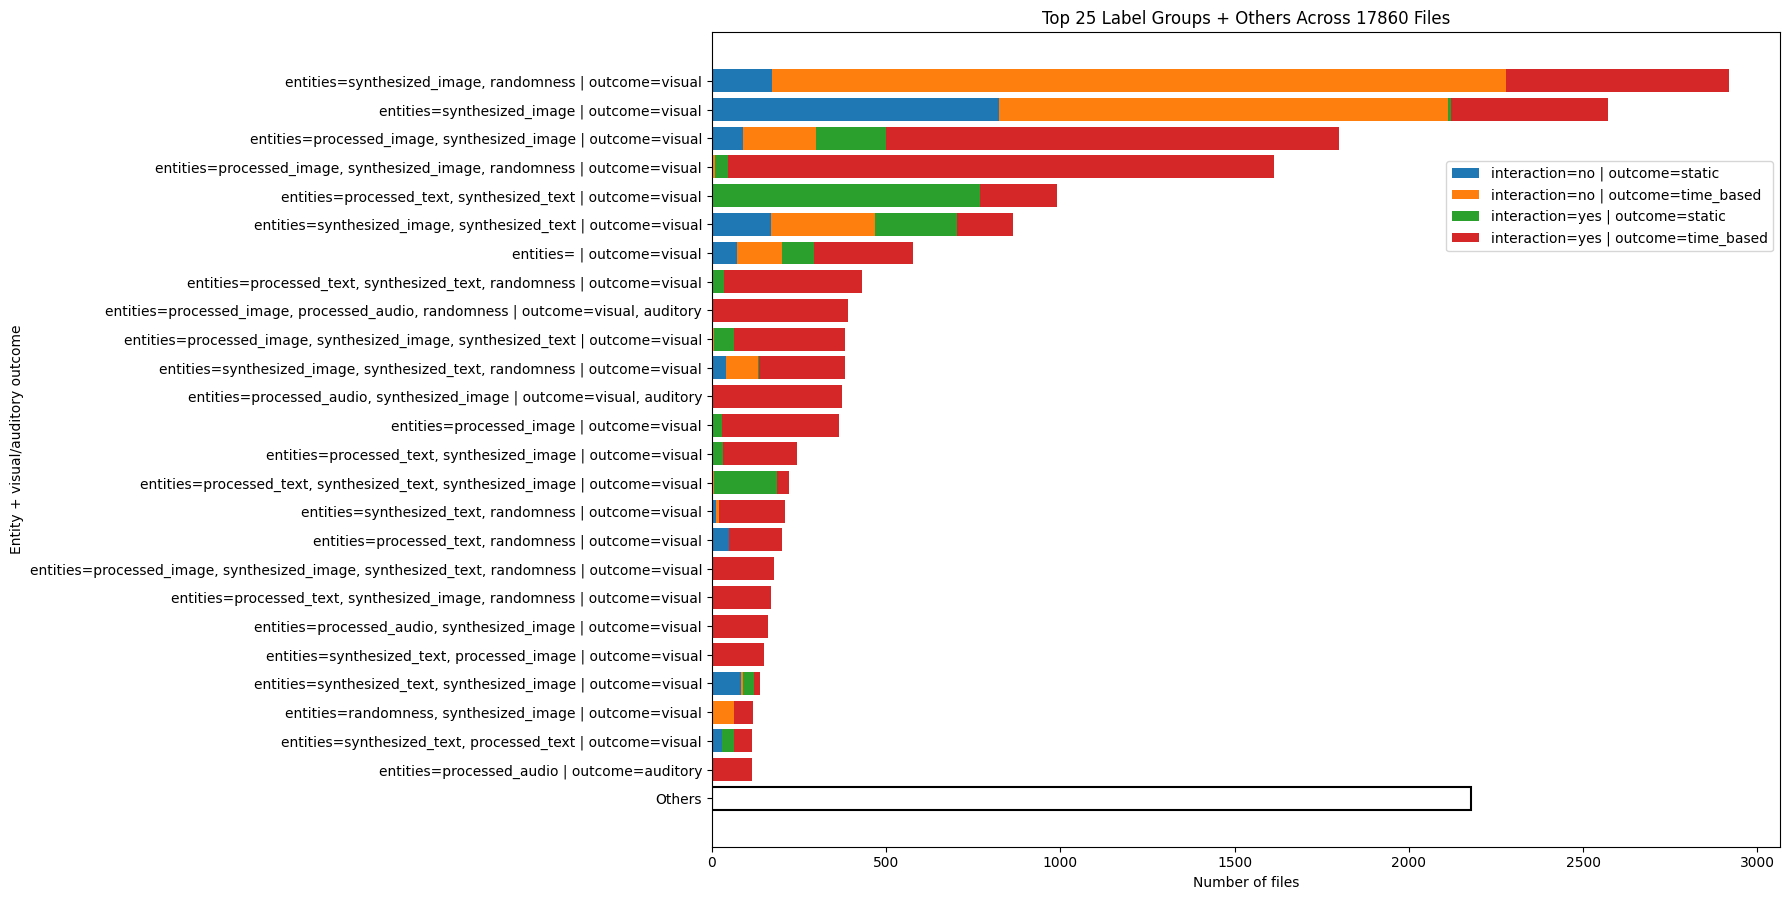

In [14]:
top_n = 25

# Remove total if it already exists
plot_data_clean = plot_data.drop(columns=["total"], errors="ignore")

# Sort rows by total bar size
totals = plot_data_clean.sum(axis=1)
plot_data_sorted = plot_data_clean.loc[
    totals.sort_values(ascending=False).index
]

# Split top 20 and others
top_data = plot_data_sorted.head(top_n)
other_total = plot_data_sorted.iloc[top_n:].sum().sum()

has_others = other_total > 0

y_labels = list(top_data.index)
if has_others:
    y_labels.append("Others")

y = np.arange(len(y_labels))

fig, ax = plt.subplots(
    figsize=(18, max(5, len(y_labels) * 0.35))
)

# Plot stacked bars for top 20
left = np.zeros(len(top_data))

for col in top_data.columns:
    values = top_data[col].values

    ax.barh(
        y[:len(top_data)],
        values,
        left=left,
        label=col
    )

    left += values

# Plot Others as a single uncolored outlined bar
if has_others:
    ax.barh(
        y[-1],
        other_total,
        facecolor="none",
        edgecolor="black",
        linewidth=1.5
    )

ax.set_yticks(y)
ax.set_yticklabels(y_labels)

ax.set_xlabel("Number of files")
ax.set_ylabel("Entity + visual/auditory outcome")
ax.set_title(f"Top {top_n} Label Groups + Others Across {len(preds)} Files")

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1, 0.85)
)

ax.invert_yaxis()

plt.tight_layout()
plt.show()

---

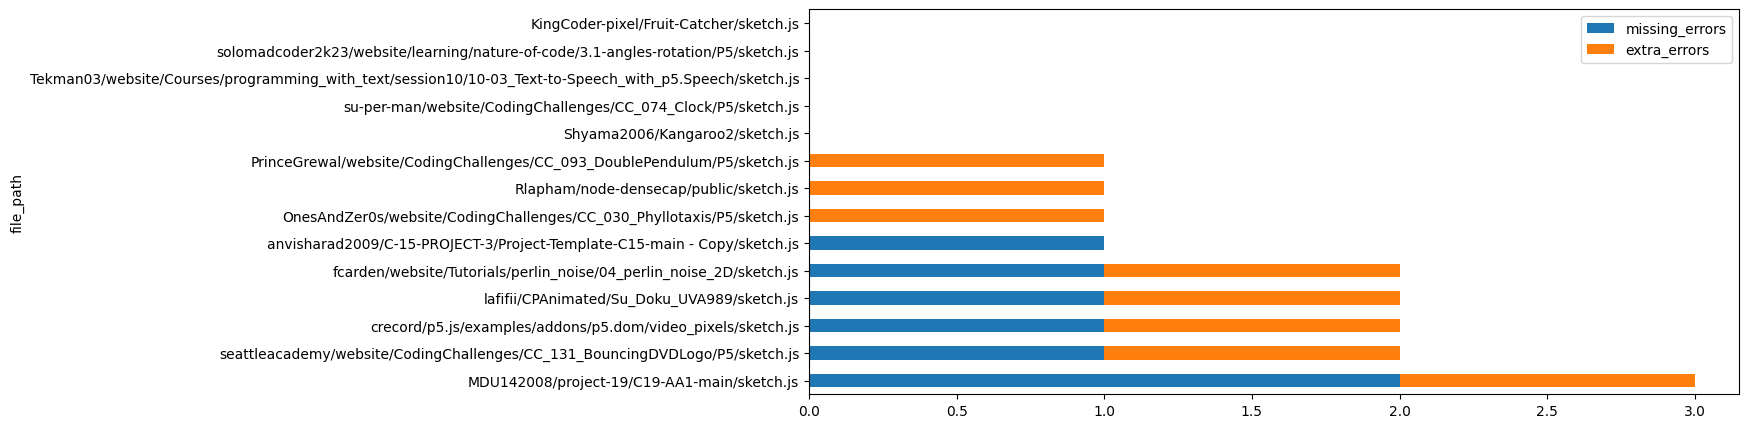

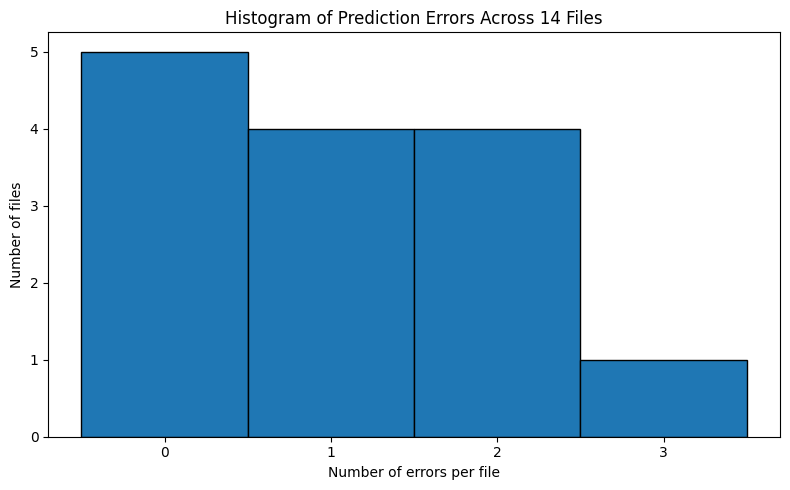

In [39]:
manual_path = "../data/manual-sampling-25-artworks.json"

with open(manual_path, "r", encoding="utf-8") as f:
    manual_data = json.load(f)

def normalize_path(path):
    path = str(path)
    return path.split("/artworks/src/")[-1].lstrip("/")

preds_by_path = {
    normalize_path(item["file_path"]): item
    for item in preds
}

manual_by_path = {
    normalize_path(item["file_path"]): item
    for item in manual_data
    if "manual_labels" in item
}

rows = []

label_groups = ["entities", "interaction", "outcome"]

for file_path, manual_item in manual_by_path.items():
    pred_item = preds_by_path.get(file_path)

    if pred_item is None:
        continue

    manual_labels = manual_item["manual_labels"]
    predicted_labels = pred_item["predicted_labels"]

    missing_count = 0
    extra_count = 0

    missing_labels = []
    extra_labels = []

    for group in label_groups:
        manual_set = set(manual_labels.get(group, []))
        predicted_set = set(predicted_labels.get(group, []))

        missing = manual_set - predicted_set
        extra = predicted_set - manual_set

        missing_count += len(missing)
        extra_count += len(extra)

        missing_labels.extend([f"{group}: {label}" for label in missing])
        extra_labels.extend([f"{group}: {label}" for label in extra])

    rows.append({
        "file_path": file_path,
        "missing_errors": missing_count,
        "extra_errors": extra_count,
        "total_errors": missing_count + extra_count,
        "missing_labels": missing_labels,
        "extra_labels": extra_labels,
    })

errors_df = pd.DataFrame(rows)

errors_plot = (
    errors_df
    .sort_values("total_errors", ascending=False)
    .set_index("file_path")[["missing_errors", "extra_errors"]]
)

ax = errors_plot.plot(
    kind="barh",
    stacked=True,
    figsize=(12, max(5, len(errors_plot) * 0.35))
)

plt.figure(figsize=(8, 5))

plt.hist(
    errors_df["total_errors"],
    bins=range(errors_df["total_errors"].max() + 2),
    align="left",
    edgecolor="black"
)

plt.xlabel("Number of errors per file")
plt.ylabel("Number of files")
plt.title(f"Histogram of Prediction Errors Across {len(errors_df)} Files")

plt.xticks(range(errors_df["total_errors"].max() + 1))

plt.tight_layout()
plt.show()

In [40]:
# see which files were not included

manual_paths = {
    normalize_path(item["file_path"])
    for item in manual_data
    if "manual_labels" in item
}

pred_paths = {
    normalize_path(item["file_path"])
    for item in preds
}

missing_in_preds = sorted(manual_paths - pred_paths)

print("Manual files not found in preds:", len(missing_in_preds))

for path in missing_in_preds:
    print(path)

without_manual_labels = [
    normalize_path(item["file_path"])
    for item in manual_data
    if "manual_labels" not in item
]

print("Files without manual_labels:", len(without_manual_labels))

for path in without_manual_labels:
    print(path)

Manual files not found in preds: 0
Files without manual_labels: 11
DravinamIND/The-End/sketch.js
MaxwellMayor/-n-k-jljjljjln/sketch.js
abhijit-dhar/website/learning/ml5/7.3_pose_regression/2_loading_data/sketch.js
idea456/website/CodingChallenges/CC_035.1_TSP/P5/sketch.js
idea456/website/CodingChallenges/CC_081.2_Circle_Morphing_Part_2/P5/sketch.js
remeyama/website/Tutorials/P5JS/p5.js/08/8.13_p5.js_Assign_a_CSS_class_dynamically/sketch.js
indefinit/AlexandrosLotsos-CreativeCoding/HW1/Painting 130/sketch.js
Vishal-cod/website-3/Tutorials/P5JS/p5.js/08/8.07_p5.js_The_basics_of_CSS/sketch.js
quintvanzijl/Rainbow-Code/A2Z/session9/9-02_FirebaseSavingData/sketch.js
Anninster/website/CodingChallenges/CC_077_Recursion/P5/sketch.js
djhprojects/website/CodingChallenges/CC_123_ChaosGame_2/P5/sketch.js
